# Reinforcement Learning

At the basis of many algorithms applied in Reinforcement learning the dynamic programming principle (DPP) lies, which we shall introduce in detail in the sequel. We shall first need the notion of a Markov process.

We shall work in the category of Feller processes, however, proofs will be presented in detail only in the case of Markov chains, i.e. Feller processes on finite state space. The mathematical notion of the state space is in computer science of referred to as environment.

Let $X$ be a compact state space (more generally, locally compact with adjoint cemetary state $\Delta$). A Feller semigroup is a strongly continuous semigroup of bounded linear operators $ (P_t) $ acting on real valued continuous functions $ f \in C(X) $ with
1. $P_t f \geq 0 $ for all $ f \geq 0 $,
2. $P_t 1 = 1 $,
for all $ t \geq 0 $.

Strong continuity can be characterized by
$$
\lim_{t \to 0} P_t f(x) = f(x)
$$
for all $ x \in X $ and $ f \in C(X) $ for linear semigroups of bounded, positive linear operators with $ P_t 1 = 1 $ for $ t \geq 0 $. We shall denote its generator by $ A $ usually only densely defined on $ \operatorname{dom}(A) $. A densely defined operator $A$ which satisfies the positive maximum principle, i.e. $ A f(z) \leq 0 $ whenever $ f \leq f(z) $ for some $ z \in X $ and $ f \in \operatorname{dom}(A) $, and for which exists $ \lambda > 0 $ such that $ \operatorname{rg}(\lambda - A ) $ is dense in $ C(X) $ is the generator of a Feller semigroup (this is the contents of the [Lumer-Phillips theorem](https://en.wikipedia.org/wiki/Lumer%E2%80%93Phillips_theorem)).

For all details on Feller semigroups see the excellent textbook of [Ethier-Kurtz](https://onlinelibrary.wiley.com/doi/book/10.1002/9780470316658).

For every Feller semigroup $ (P_t)_{t \geq 0} $ we can construct a family of measures $ \mathbb{P}_x $ for $ x \in X $ on path space $ D([0,\infty[) $ such that the canonical process $ (x(t))_{t \geq 0} $ is a Markov process for each measure $ \mathbb{P}_x $ starting at $ x \in X $ with Markov semigroup $ (P_t)_{t \geq 0} $, i.e.
$$
E_x \big[ f(x(t)) \, | \; \mathcal{F}_s \big] = E_y \Big . \big[ f(x(t-s) \big]\Big|_{y = x(s)}
$$
$\mathbb{P}_x $ almost surely as well as
$$
E_x[f(x(t))] = P_t f(x)
$$
each for all $ f \in C(X) $ and $ 0 \leq s \leq t$. In particular we have that
$$
(P_{t-s}f(x(s)))_{0 \leq s \leq t} \text{ or } \big( f(x(t)) - f(x(0)) - \int_0^t A f(x(s)) ds \big)_{t \geq 0}
$$
are $ \mathbb{P}_x $-martingales for every $ x \in X $ and every $ f \in C(X) $, or $ f \in \operatorname{dom}(A) $, respectively, and $ x(0) = x $ $\mathbb{P}_x $ almost surely.

We shall focus in the sequel on $ X = \{1,\ldots,n \} $. In this case the strongly continuous semigroup is uniformly continuous and in the representation $C(X) = \mathbb{R}^n $ the generator $A$ is a stochastic matrix, i.e. diagonal elements are non-positive, off-diagonal elements non-negative and rows sum up to zero. Then and only then $ P_t = \exp(At) $ defines a Feller semigroup.

Let us define jump measures on $ X $ by
$$
\mu(i,.) = \frac{1}{\sum_{i \neq k} a_{ik}} \sum_{k\neq i} a_{ik} \delta_{k}
$$
if $ - a_{ii} =  \sum_{i \neq k} a_{ik} > 0 $, otherwise $ \mu(i,.) = 0 $. Then the pure jump process which jumps with intensity $ -a_{ii} $ at $ i \in X $ with jump measure $ \mu(i,.) $ coincides with the Markov process associated to the above Feller semigroup.

In the sequel we shall consider two examples: first a discrete time Markov chain, which is first simulated on a discrete grid, and then with exponential jumping times (think about the relationship of the two different but similar processes), and, second, a Markov process on $ \{1, 2, 3 \} $ in order to understand the jump structure.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
N = 100  # maximum population size
a = .5 / N  # birth rate
b = .5 / N  # death rate

lifetime = 1000
x = np.zeros(lifetime)
x[0] = 25

In [ ]:
for t in range(lifetime - 1):
    if 0 < x[t] < N - 1:
        # Is there a birth?
        birth = np.random.rand() <= a * x[t]*(x[t]<N-1)
        # Is there a death?
        death = np.random.rand() <= b * x[t]
        # We update the population size.
        x[t + 1] = x[t] + 1 * birth - 1 * death
    # The evolution stops if we reach $0$ or $N$.
    else:
        x[t + 1] = x[t]

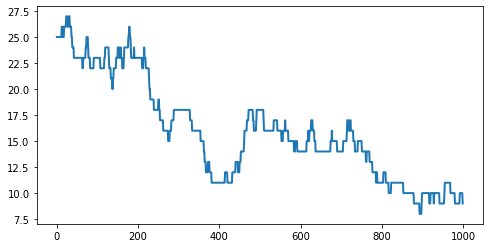

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(x, lw=2)

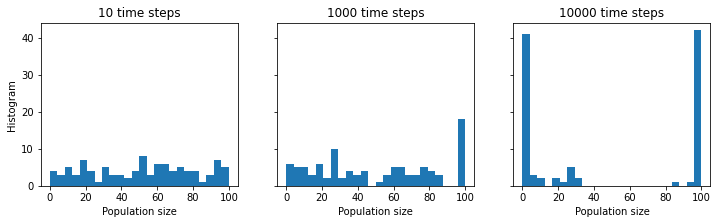

In [ ]:
ntrials = 100
x = np.random.randint(size=ntrials,
                      low=0, high=N)

def simulate(x, lifetime):
    """Run the simulation."""
    for _ in range(lifetime - 1):
        # Which trials to update?
        upd = (0 < x) & (x < N - 1)
        # In which trials do births occur?
        birth = 1 * (np.random.rand(ntrials) <= a * x * (x<N-1))
        # In which trials do deaths occur?
        death = 1 * (np.random.rand(ntrials) <= b * x)
        # We update the population size for all trials
        x[upd] += birth[upd] - death[upd]

bins = np.linspace(0, N, 25)

lifetime_list = [10, 1000, 10000]
fig, axes = plt.subplots(1, len(lifetime_list),
                         figsize=(12, 3),
                         sharey=True)
for i, lifetime in enumerate(lifetime_list):
    ax = axes[i]
    simulate(x, lifetime)
    ax.hist(x, bins=bins)
    ax.set_xlabel("Population size")
    if i == 0:
        ax.set_ylabel("Histogram")
    ax.set_title(f"{lifetime} time steps")

In [ ]:
initial = 25
lifetime = 1000
jumptimes = np.zeros(1)
y = np.ones(1)*initial
t = 0
while t < lifetime:
    s = np.random.exponential(1,1)
    jumptimes = np.append(jumptimes,np.array([s+t]))
    t = t + s
    if 0 < y[-1] < N - 1:
        # Is there a birth?
        birth = np.random.rand() <= a * y[-1]
        # Is there a death?
        death = np.random.rand() <= b * y[-1]
        # We update the population size.
        helper = y[-1] + 1 * birth - 1 * death
    # The evolution stops if we reach $0$ or $N$.
    else:
        helper = y[-1]
    y = np.append(y,np.array([helper]))

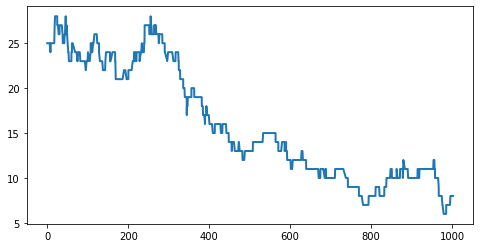

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(jumptimes,y, lw=2)

In [ ]:
#define stochastic matrix
A = np.array([[-5, 4, 1], [4, -5, 1], [2, 2, -4]])

In [ ]:
#define jump measures
from scipy import stats

jumpmeasures = []
for i in range(3):
    values = [j for j in range(3)]
    xk = np.array(values)
    pk = np.array([-A[i,j]/A[i,i]*(j!=i) for j in values])
    custm = stats.rv_discrete(values=(xk, pk))
    jumpmeasures = jumpmeasures + [custm]

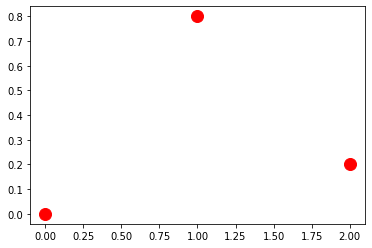

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1)
ax.plot(xk, jumpmeasures[0].pmf(xk), 'ro', ms=12, mec='r')
plt.show()

In [ ]:
lifetime = 5
initial = 0
jumptimes = np.zeros(1)
y = np.ones(1)*initial
t = 0
while t < lifetime:
    tau = np.random.exponential(-1/A[int(y[-1]),int(y[-1])],1)
    jumptimes = np.append(jumptimes,np.array([tau+t]))
    t = t + tau
    helper = jumpmeasures[int(y[-1])].rvs(size=1)
    y = np.append(y,np.array([helper]))

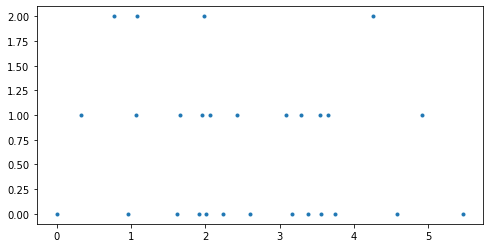

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(jumptimes,y,'.')

In [ ]:
lifetime = 20
initial = 0
jumptimes = np.zeros(1)
y = np.ones(1)*initial
t = 0
def control(t,y):
    if t < 10:
        return 1*(2*y+1)
    else:
        return 1*(2*y+1)

while t < lifetime:
    A = control(t,y[-1])*np.array([[-5, 4, 1], [4, -5, 1], [2, 2, -4]])
    tau = np.random.exponential(-1/A[int(y[-1]),int(y[-1])],1)
    jumptimes = np.append(jumptimes,np.array([tau+t]))
    t = t + tau
    jumpmeasures = []
    for i in range(3):
        values = [j for j in range(3)]
        xk = np.array(values)
        pk = np.array([-A[i,j]/A[i,i]*(j!=i) for j in values])
        custm = stats.rv_discrete(values=(xk, pk))
        jumpmeasures = jumpmeasures + [custm]
    helper = jumpmeasures[int(y[-1])].rvs(size=1)
    y = np.append(y,np.array([helper]))

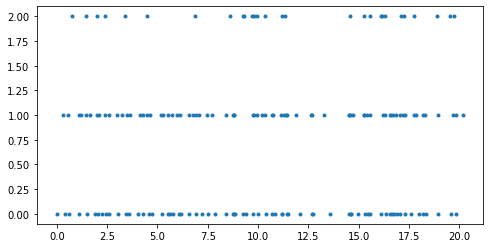

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(jumptimes,y,'.')

There are two ways of thinking about Markov processes: on a stochasic basis or on path space. The second one puts emphasis on different measures subject to different controls, the first one different processes subject to different controls. We shall take here the first approach, even though we have introduced above a path space perspective and the second one appears more natural and sometime also slightly more general. Let $ (\Omega,\mathcal{F},\mathbb{P}) $ be a stochastic basis. We shall furthermore consider a finite set $ U $ of controls (actions) such that $ (A^u)_{u \in U} $ is a family of Feller generators on (the finite set) $ X $ depending (continuously of course) on $U$.

What is a control $ \pi \in \Pi $? In principle it is a map from the current state (and possibly also its past) to $U$, so a predictable process on path space, where the current process is inserted. This is notationally a bit delicate. We shall write $ \pi_s $ when we actually mean the evaluation of the control at time $s$ with process $ x^\pi $ (defined below) inserted, i.e. $ \pi_s = \pi(s,x^\pi(.-)) $. Without loss of generality it is possible to think of $ \pi_s $ just depending on the current state, i.e. $ \pi_s = \pi(s,x^\pi(s-)) $ due to the Markovian nature of the problem. Notationally we should use a different sign for the control $ \pi \in \Pi $ and the process $ (\pi_s) $ but it is less heavy to identify them.

We shall now consider controlled processes $x^\pi$ on our stochastic basis, controlled by controls $ \pi \in \Pi $, starting at $x \in X $ at time $r$, such that
$$
\big(f(x^\pi(t))-f(x^\pi(r)) - \int_r^t A^{\pi_s} f(x^\pi(s)) ds \big)_{t \geq 0}
$$
is a $\mathbb{P}$-martingale for every $ \pi \in \Pi $ and $ f \in \cap_{u \in U} \operatorname{dom}(A^u) $. We shall use the notation $E_{r,x}$ when we want to express that $x(r) = x $ almost surely on our stochastic basis.

Let $ R : X \to \mathbb{R} $ be a reward function and $ c: [0,\infty[ \times X \times U \to \mathbb{R} $ be a continuous cost function.

We shall always assume the following propery for the set of strategies (policies) $\Pi$:

For all $ \pi \in \Pi $ and for all $ T \geq t \geq s \geq 0 $ we have the dynamic programming property, namely that
$$
\sup_{\pi \in \Pi} E_{s,x} \big[R(x^\pi(T)) + \int_s^T c(r,x^\pi(r),\pi_r)dr  \big] = \sup_{\pi \in \Pi} E_{s,x} \Big[ \Big( \sup_{\pi \in \Pi} E_{t,y} \big[ R(x^\pi(T)) + \int_t^T c(r,x^\pi(r),\pi_r)dr \big] \Big)|_{y=x^\pi(t)} + \int_s^t c(r,x^\pi(r),\pi_r)dr \Big] \, .
$$
This means nothing else than: optimizing from $t$ to the final time $T$, given a certain state $y$ at $t$, and then optimizing from $s$ to $t$ yields the same result as optimizing from $s$ to $T$.

We shall now consider a stochastic optimization problem, namely
$$
\sup_{\pi \in \Pi} E_x\big[ R(x^\pi(T)) + \int_0^T c(s,x^\pi(s),\pi_s) ds \big]
$$
for $ x \in X $. We shall solve this problem by dynamization, i.e. consider
$$
V^\ast(t,x) := \sup_{\pi \in \Pi} E_{t,x}\big[ R(x^\pi(T)) + \int_t^{T} c(s,x^\pi(s),\pi_s) ds \big] $$
for $ x \in X $ and $ 0 \leq t \leq T $.

By virtue of this defintion we obtain the dynamic programming principle (DPP): for $ 0 \leq s \leq t \leq T $ we have that
$$
V^\ast(s,x) = \sup_{\pi \in \Pi} E_{s,x} \big[ V^\ast(t,x^\pi(t)) + \int_s^t c(r,x^\pi(r),\pi_r) dr \big] \, .
$$

The proof is by insertion:
$$
V^\ast(s,x) = \sup_{\pi \in \Pi} E_{s,x} \big[ R(x^\pi(T)) + \int_s^T c(r,x^\pi(r),\pi_r) dr \big] = \sup_{\pi \in \Pi} E_{s,x} \big[ R(x^\pi(T)) + \int_s^t + \int_t^T c(r,x^\pi(r),\pi_r) dr \big] \, ,
$$
where the integral is split into integration from $s$ to $ t $ and from $ t $ to $T$. By the dynamic programing property this yields the result, i.e.
$$
\sup_{\pi \in \Pi} E_{s,x} \big[ R(x^\pi(T)) + \int_s^t + \int_t^T c(r,x^\pi(r),\pi_r) dr \big] = \sup_{\pi \in \Pi} E_{s,x} \Big[ \Big( \sup_{\pi \in \Pi} E_{t,y} \big [ R(x^\pi(T)) + \int_t^T c(r,x^\pi(r),\pi_r) \big] dr \Big)|_{y=x^\pi(t)} + \int_s^t \Big]
$$

In the case of finite $X$ no regularity issues arise and we can consider the derivative of the dynamic programming equation yielding
$$
\partial_t V^\ast(t,x) + \sup_{u \in U} (A^u V^\ast(t,x)  + c(t,x,u)) = 0
$$
for $ x \in X $ and $ 0 \leq t \leq T $ with $ V^\ast(T,x) = R(x) $ for $ x \in X $.

From DPP we can immediately derive that a strategy $ \pi $ is optimal for the optimization problem if and only if
$$
(V^*(t,x^\pi(t))+\int_0^tc(r,x^\pi(r),\pi_r)dr)_{0 \leq t \leq T}
$$
is a $ \mathbb{P} $ martingale for all initial $ x \in X$.

Indeed, let the previous expression be a martingale for some strategy $ \pi $, then
$$
E_x \big[ R(x^\pi(T))+\int_0^Tc(r,x^\pi(r),\pi_r)dr \big]=V^\ast(0,x) \,
$$
which is precisely the optimality condition. Let $ \pi $ be any strategy, then
$$
V^*(t,x^\pi(t))+\int_0^tc(r,x^\pi(r),\pi_r)dr = V^*(0,x) + \int_0^t \big(\partial_r V^\ast(r,x^\pi(r))+ A^{\pi_r} V^*(r,x^\pi(r))+c(r,x^\pi(r),\pi_r)\big)dr + \text{ martingale }
$$
is a $ \mathbb{P} $ supermartingale for all intial values $ x \in X $.

Finally let us assume that there is a measurable function $ \pi(s,.) $ from $ X $ to $ U $ such that
$$
\pi(s,x) \in \operatorname{argmax}_{u \in U} (A^u V^\ast(s,x) + c(s,x,u)) \, ,
$$
such that $ \pi^*_s := \pi(s,x(s-)) $ for $ s \geq 0 $ is an element of $ \Pi $, then the above martingale condition is satisfied.

Similar conditions can be derived in case of time discrete or infinite time horizon problems: let us formulate DPP for a time discrete infinite time horizon problem with objective function
$$
\sup_{\pi \in \Pi} E_x\big[ \sum_{\tau \geq s \geq 0} \gamma^s r(x^\pi(s)) \big] \, ,
$$
where $ \tau $ is the first time terminal states are reached and $ \gamma $ is usually a discounting factor, so less than one. Since the problem is infinite horizon the value function does not depend on time (stationary case). DPP then reads as follows
$$
V^\ast(x) =\gamma \sup_{u \in U} P_1^u V^\ast (x) + r(x) \, ,
$$
which can be solved by a Banach fixed point principle. Again the optimal strategy (policy) can be found by looking at
$$
\pi^\ast(x) \in \operatorname{argmax}_{u \in U} P_1^u V^\ast(x) \,
$$
for $ x $ not terminal. This is clearly the case since
$$
V^\ast(x) =\gamma P_1^{\pi^\ast(x)} V^\ast (x) + r(x) \, ,
$$
for $ x $ not terminal, which means by iteration
$$
V^\ast(x) = E_x\big[ \sum_{\tau \geq s \geq 0} \gamma^s r(x^{\pi^\ast}(s)) \big] \, .
$$

An important concept for future considerations is the Q-function:
$$
Q^*(x,u) := r(x) + \gamma P_1^u V^*(x)
$$
from which we can of course calculate $ V^* $.

In this very case we can distinguish three cases of finding solutions of the problem:
1. (Value iteration) Solve the Bellman equation by a Banach fixed point argument. Choose an arbitrary initial value function $ V^{(0)} $, then perform
$$
Q^{(n+1)}(x,u) = \gamma P_1^u V^{(n)}(x) + r(x); V^{(n+1)}(x) = \sup_{u \in U} Q^{(n+1)}(x,u) \, .
$$
2. (Policy iteration) Choose an initial strategy $ \pi^{(0)} $ and calculate its value function recursively via
$$
V^{\pi^{(n)}}(x) = E_x\big[ \sum_{\tau \geq s \geq 0} \gamma^s r(x^{\pi^{(n)}}(s)) \big] \, ,
$$
then define
$$
\pi^{(n+1)}(x) \in \operatorname{argmax}_{u \in U} \gamma P_1^u V^{\pi^{(n)}}(x) + r(x) \, .
$$
3. (Q-Learning -- known environment) Choose an initial $ Q^{(0)} $ function and update via
$$
\pi^{(n)}(x) \in \operatorname{argmax}_{u \in U} Q^{(n)}(x,u) \, .
$$
and
$$
Q^{(n+1)}(x,u) = \gamma P_1^u (Q^{(n)}(.,\pi^{(n)}(.))(x) + r(x) \, .
$$
3. (Q-Learning -- unknown environment) Choose an initial $ Q^{(0)} $ function and update via a learning rate $ \alpha $ in a possibly unknown environment, i.e.
$$
Q^{(n+1)}(x,u) = (1-\alpha) Q^{(n)}(x,u) + \alpha(r(x) + \gamma \sup_{u \in U} Q^{(n)}(x',u))
$$
for some chosen state $ x' \in X $ which is reached after action $u$. When we consider $u$ a relaxed action, then this leads to the exploitation-exploration dilemma: either $x'$ is chosen according to where $ Q^{(n)}(x,.) $ takes its maximum (exploitation) or it is reached after choosing a more random action (exploration). The background of this algorithm lies in an extended version of the stochastic approximation algorithm of [Robins-Monroe](https://en.wikipedia.org/wiki/Stochastic_approximation). It reads as follows and can be found in [John Tsitsiklis famous article](https://link.springer.com/content/pdf/10.1007/BF00993306.pdf): imagine we want to solve a fixed point problem $ Q(x,u) = r(x) +\gamma P_1^u (\sup_{u \in U} Q(.,u))(x) $, then we can consider a stochastic algorithm of the following type
$$
Q^{(n+1)}(x,u) = Q^{(n)}(x,u) + \alpha(r(x)+ \gamma P_1^u (\sup_{u \in U} Q^{(n)}(.,u))(x) - Q^{(n)}(x,u) + \text{ 'noise'})
$$
with a learning rate $ \alpha $. Then one replaces
$$
P_1^u (\sup_{u \in U} Q^{(n)}(.,u))(x) + \text{ 'noise'}
$$
by an estimator for the expectation, for instance a sampled next state $ x' $, or an average over sampled states, which is proven to converge in the cited paper.
5. An approach motivated by the [Longstaff-Schwartz algorithm for optimal stopping](https://escholarship.org/uc/item/43n1k4jb) is the following. Choose a parameterized family $ \pi^{(\theta)} $ of strategies being dense in all possible strategies (in an appropriate sense) and solve directly
$$
\theta \mapsto \widehat{E_x} \big[ \sum_{\tau \geq s \geq 0} \gamma^s r(x^{\pi^{(\theta)}}(s)) \big] \, ,
$$
where $ \widehat{E_x} $ is a Monte Carlo Sampler of the expectation via gradient descent techniques for one $ x \in \{1,\ldots,n \} $ one is interested in. This can be related to $Q$ learning with $\alpha=1$ and a rich simulation.

Let us just show in this case of a simple Markov decision problem why the standard algorithms converge. We consider the fixed point equation
$$
V^*(x) = r(x) + \gamma \max_{u \in U} P_1^u V^*(x) \,
$$
for $ 0 < \gamma < 1 $.

1. (Value iteration) The Belmann operator
$$
Q \mapsto \mathcal{B}(Q) := r + \gamma \max_{u \in U} P_1^u Q
$$
is contractive. Indeed
$$
| \mathcal{B}(Q_1)(x) - \mathcal{B}(Q_2)(x) | = \gamma | \max_{u \in U} P_1^u Q_1(x) - \max_{u \in U} P_1^u Q_2(x) | \leq \gamma \max_{u \in U} | P_1^u Q_1(x) - P_1^u Q_2(x) | \leq \gamma {\| Q_1 - Q_2 \|}_\infty
$$
for all $ x \in X $. Whence we obtain an exponential convergence, i.e.
$$
|| Q^{(n)} - V^* || \leq C \gamma^n  
$$
as $ n \to \infty $ in the supremum norm. However, computations are relatively heavy due to the involved nature of the Bellmann operator.

2. (Policy iteration) Here at each step $ V^\pi $ is calculated, which is done by either calculating the expectation. The value function is improving like in value iteration. Whence again by a contraction principle one obtains convergence, but it might be much quicker due particularities of the control problem.

3. In case of $Q$ learning we rather consider the fixed point equation
$$
Q(x,u) = r(x) + \gamma P_1^u (\max_{u \in U} Q(.,u)(x)
) \, ,
$$
which is by the same argument contractive and leads to the following iteration: choose $ Q^{(0)} $ and define
$$
Q^{(n+1)}(x,u) = r(x) + \gamma P_1^u (Q^{(n)}(.,\pi^{(n)}(.)))(x) \, ,
$$
where $ \pi^{(n)}(.) \in \operatorname{argmax}_{u \in U} Q^{(n)}(x,u) $. Whence the algorithm for a known environment (i.e. we trust the $Q$ function).

4. If we are not sure about the quality of the $Q$ function and we are not willing to perform the above iteration since it is very costly, we can consider the following algorithm to solve a fixed point problem $ Q = L(Q) $
$$
Q^{(n+1)} = Q^{(n)} + \alpha (L(Q^{(n)})-Q^{(n)} + \text{'noise'}) \, .
$$
Let us additionally view relaxation here, i.e. we consider actions from $ \tilde U \subset P(U) $, a subset containing at least $ \delta_u $, for $ u \in U $. We obtain a new $\tilde Q $ function in this case depending on $ \tilde u $, but since suprema are attained at extremal points $ \delta_u$ the function only depending on $ u \in U $ is actually of importance
$$
\widetilde{Q}(x,\tilde u) = E_{\tilde{u}}[Q(x,.)] \, .
$$
It gets, however, interesting when we actually sample from this expectation.

5. In this approach we are not calculating $Q$ functions anymore but work right away with the original problem formulation. This avoids costly backward inductions.

Similar algorithms may be designed in any DPP situation with adaptions according to the structure of DPP, take for instance the previous problem for simplicity with $ c = 0 $, then value iteration, policy iteration or Q-learning are just ways to solve the HJB equation
$$
\partial_t V^\ast(t,x) + \sup_{u \in U} A^u V^\ast(t,x) = 0 \, , \; V^\ast(T,x) = R(x)
$$
on refining time grids.

A major insight into the structure and solution concepts of stochastic control problems is the following relaxation procedure: instead of considering strategies (policies) as predictable processes with values in $ U $ one considers _randomized_ strategies $ \delta_s \in \Delta(U) $ (again with predictable time dependence). The corresponding martingale problem is
$$
\Big(f(x^\delta(t))-f(x) - \int_0^t \big (\int_U A^{u} f  \delta_s(du) \big)(x^{\delta}(s))  ds \Big)_{t \geq 0}
$$
is a $\mathbb{P}_x $-martingale for every $ x \in X $ and $ f \in \cap_{u \in U} \operatorname{dom}(A^u) $, i.e. the control has an additional randomness before actually acting on the environment.

This relaxation has two advantages: first the set of controls is a convex set and the controlled generator depends linearly on the control, and, second, a more robust solution theory is achieved in case 'classical' solutions are difficult to construct.

The HJB equation looks then then same (under mild regularity assumptions)
$$
\partial_t V^\ast(t,x) + \sup_{\delta \in \Delta(U)} \int_U A^\delta V^\ast (t,x) \delta(du) = \sup_{u \in U} A^u V^\ast (t,x) = 0 \, ,
$$
however, new algorithms can emerge.

Let us look again at the algorithms from the point of view of the above HJB equation, fix an equidistant grid in time $ 0 = t_0 < t_1 \dots < t_n = T $ with mesh $ \Delta t $:
1. (Value iteration) We solve backwards: $V^{(n)}(t_n,x) = R(x) $ and
$$
V^{(n)}(t_i,x) = \sup_{u \in U} P^u_{\Delta t} V^{(n)}(t_{i+1},.)(x)
$$
for $ 0 \leq i < n $, which yields under weak regularity assumption a converging scheme.
2. (Policy iteration) We choose a policy $ \pi^{(n)}(t_i,.) $ and calculate the value function for this very policy via $ V^{\pi^{(n)}}(t_n,x) = R(x) $
$$
V^{\pi^{(n)}}(t_i,x) =  P^{\pi^{(n)}(x)}_{\Delta t} V^{\pi{(n)}}(t_{i+1},.)(x) \, .
$$
Then we optimize the policy at one intermediate point $ t_i $ and at one $ x \in X $.

As a last theoretical step we move forward to Markov games, i.e. situation where several independent agents optimize their strategies. Again we shall be able to formulate dynamic programmig principles. Situation is actually very similar and we just formulate the according principles.

We shall consider two finite sets $ U_1 $ and $ U_2$ of controls (actions) such that $ (A^{(u_1,u_2)})_{u \in U_1 \times U_2} $ is a family of Feller generators on (the finite set) $ X $ depending (continuously of course) on $U := U_1 \times U_2$. We shall consider the set $ x^{(\pi_1,\pi_2)} $ of processes with values in $X$ controlled by controls $ \pi := (\pi_1,\pi_2) \in \Pi := \Pi_1 \times \Pi_2 $, a set of predictable process taking values in $U_1 \times U_2$ defined on path space (see above), starting at $x$ at time $r$, such that
$$
\big(f(x^\pi_1(t))-f(x) - \int_r^t A^{\pi_s} f(x^{\pi}(s)) ds \big)_{t \geq 0}
$$
is a $\mathbb{P} $-martingale for every $ f \in \cap_{u \in U} \operatorname{dom}(A^u) $.

Let $ R : X \to \mathbb{R} $ be again a reward function and $ c: [0,\infty[ \times X \times U \to \mathbb{R} $ be a continuous cost function.

We shall always assume the following property for the set of strategies (policies) $\Pi$:

For all $ \pi \in \Pi $ and $ T \geq t \geq s \geq 0 $ we have the dynamic programming property namely that
$$
\sup_{\pi_1 \in \Pi_1} \inf_{\pi_2 \in \Pi_2} E_{s,x} \big[R(x^\pi(T)) + \int_t^T c(r,x^\pi(r),\pi_r)dr  \big] = \sup_{\pi_1 \in \Pi_1} \inf_{\pi_2 \in \Pi_2} E_{s,x} \Big[ \Big ( \sup_{\pi_1 \in \Pi_1} \inf_{\pi_2 \in \Pi_2} E_{t,y} \big[ R(x^\pi(T)) + \int_t^T c(r,x^\pi(r),\pi_r)dr \big]\Big)|_{y=x^\pi(t)} + \int_s^t c(r,x^\pi(r),\pi_r)dr \Big] \, ,
$$
furthermore
$$
\inf_{\pi_1 \in \Pi_1} \sup_{\pi_2 \in \Pi_2} E_{s,x} \big[R(x^\pi(T)) + \int_t^T c(r,x^\pi(r),\pi_r)dr  \big] = \inf_{\pi_1 \in \Pi_1} \sup_{\pi_2 \in \Pi_2} E_{s,x} \Big[ \Big ( \inf_{\pi_1 \in \Pi_1} \sup_{\pi_2 \in \Pi_2} E_{t,y} \big[ R(x^\pi(T)) + \int_t^T c(r,x^\pi(r),\pi_r)dr \big]\Big)|_{y=x^\pi(t)} + \int_s^t c(r,x^\pi(r),\pi_r)dr \Big] \, ,
$$
and
$$
\sup_{\pi_1 \in \Pi_1} \inf_{\pi_2 \in \Pi_2} E_{s,x} \big[R(x^\pi(T)) + \int_t^T c(r,x^\pi(r),\pi_r)dr  \big] = \inf_{\pi_2 \in \Pi_2} \sup_{\pi_1 \in \Pi_1} E_{s,x} \big[R(x^\pi(T)) + \int_t^T c(r,x^\pi(r),\pi_r)dr  \big] \, .
$$

Under these assumptions a completely analog dynamic programming principle for this zero sum two player Markov game can be formulated. The game is obviously (Markov) stochastic due since each of the two players just controls a Markov process. It is furthermore _zero sum_ since a gain for player 1 means a loss for player 2. The _Isaacs condition_ of interchanging suprema and infima allows to interpret the solution as Nash equilibrium, i.e. no player cannot improve her situation if the other one plays a fixed strategy. There is only one value function which satisfies DPP for $ 0 \leq s \leq t \leq T $ we have that
$$
V^\ast(s,x) = \sup_{\pi_1 \in \Pi_1} \inf_{\pi_2 \in \Pi_2} E_{s,x} \big[ V^\ast(t,x^\pi(t)) + \int_s^t c(r,x^\pi(r),\pi_r) dr \big] \, , \; V^\ast(T,x) = R(x)
$$
leading the the HJB equation
$$
\partial_t V^\ast(t,x) + \sup_{u \in U_1} \inf_{u_2 \in U_2} (A^{u_1,u_2} V^\ast(t,x)  + c(t,x,u_1,u_2)) = 0
$$
for $ x \in X $ and $ 0 \leq t \leq T $ with $ V^\ast(T,x) = R(x) $ for $ x \in X $. In the finite state space case this can be proved under mild regularity assumptions.

Generalization are similar: policies can be relaxed, more the 2 players can be considered and also non-zero sum games can be considered.

In the sequel several games from the [AI project](https://gym.openai.com/) are shown to illustrate and deepen concepts.

In [ ]:
"""
Solving FrozenLake8x8 environment using Value-Itertion.
Author : Moustafa Alzantot (malzantot@ucla.edu)
"""
import numpy as np
import gym
from gym import wrappers


def run_episode(env, policy, gamma = 1.0, render = True):
    """ Evaluates policy by using it to run an episode and finding its
    total reward.
    args:
    env: gym environment.
    policy: the policy to be used.
    gamma: discount factor.
    render: boolean to turn rendering on/off.
    returns:
    total reward: real value of the total reward recieved by agent under policy.
    """
    obs = env.reset()
    total_reward = 0
    step_idx = 0
    while True:
        if render:
            env.render()
        obs, reward, done , _ = env.step(int(policy[obs]))
        total_reward += (gamma ** step_idx * reward)
        step_idx += 1
        if done:
            break
    return total_reward


def evaluate_policy(env, policy, gamma = 1.0,  n = 100):
    """ Evaluates a policy by running it n times.
    returns:
    average total reward
    """
    scores = [run_episode(env, policy, gamma = gamma, render = False) for _ in range(n)]
    return np.mean(scores)

def extract_policy(v, gamma = 1.0):
    """ Extract the policy given a value-function """
    policy = np.zeros(env.nS)
    for s in range(env.nS):
        q_sa = np.zeros(env.action_space.n)
        for a in range(env.action_space.n):
            for next_sr in env.P[s][a]:
                # next_sr is a tuple of (probability, next state, reward, done)
                p, s_, r, _ = next_sr
                q_sa[a] += (p * (r + gamma * v[s_]))
        policy[s] = np.argmax(q_sa)
    return policy


def value_iteration(env, gamma = 1.0):
    """ Value-iteration algorithm """
    v = np.zeros(env.nS)  # initialize value-function
    max_iterations = 100000
    eps = 1e-20
    for i in range(max_iterations):
        prev_v = np.copy(v)
        for s in range(env.nS):
            q_sa = [sum([p*(r + prev_v[s_]) for p, s_, r, _ in env.P[s][a]]) for a in range(env.nA)]
            v[s] = max(q_sa)
        if (np.sum(np.fabs(prev_v - v)) <= eps):
            print ('Value-iteration converged at iteration# %d.' %(i+1))
            break
    return v

In [ ]:
env_name  = 'FrozenLake8x8-v0'
gamma = 1.0
env = gym.make(env_name)
env=env.unwrapped
optimal_v = value_iteration(env, gamma);
policy = extract_policy(optimal_v, gamma)
policy_score = evaluate_policy(env, policy, gamma, n=1000)
print('Policy average score = ', policy_score)

Value-iteration converged at iteration# 2357.
Policy average score =  1.0


In [ ]:
"""
Solving FrozenLake8x8 environment using Policy iteration.
Author : Moustafa Alzantot (malzantot@ucla.edu)
"""
import numpy as np
import gym
from gym import wrappers


def run_episode(env, policy, gamma = 1.0, render = False):
    """ Runs an episode and return the total reward """
    obs = env.reset()
    total_reward = 0
    step_idx = 0
    while True:
        if render:
            env.render()
        obs, reward, done , _ = env.step(int(policy[obs]))
        total_reward += (gamma ** step_idx * reward)
        step_idx += 1
        if done:
            break
    return total_reward


def evaluate_policy(env, policy, gamma = 1.0, n = 100):
    scores = [run_episode(env, policy, gamma, False) for _ in range(n)]
    return np.mean(scores)

def extract_policy(v, gamma = 1.0):
    """ Extract the policy given a value-function """
    policy = np.zeros(env.nS)
    for s in range(env.nS):
        q_sa = np.zeros(env.nA)
        for a in range(env.nA):
            q_sa[a] = sum([p * (r + gamma * v[s_]) for p, s_, r, _ in  env.P[s][a]])
        policy[s] = np.argmax(q_sa)
    return policy

def compute_policy_v(env, policy, gamma=1.0):
    """ Iteratively evaluate the value-function under policy.
    Alternatively, we could formulate a set of linear equations in iterms of v[s]
    and solve them to find the value function.
    """
    v = np.zeros(env.nS)
    eps = 1e-10
    while True:
        prev_v = np.copy(v)
        for s in range(env.nS):
            policy_a = policy[s]
            v[s] = sum([p * (r + gamma * prev_v[s_]) for p, s_, r, _ in env.P[s][policy_a]])
        if (np.sum((np.fabs(prev_v - v))) <= eps):
            # value converged
            break
    return v

def policy_iteration(env, gamma = 1.0):
    """ Policy-Iteration algorithm """
    policy = np.random.choice(env.nA, size=(env.nS))  # initialize a random policy
    max_iterations = 200000
    gamma = 1.0
    for i in range(max_iterations):
        old_policy_v = compute_policy_v(env, policy, gamma)
        new_policy = extract_policy(old_policy_v, gamma)
        if (np.all(policy == new_policy)):
            print ('Policy-Iteration converged at step %d.' %(i+1))
            break
        policy = new_policy
    return policy

In [ ]:
env_name  = 'FrozenLake8x8-v0'
env = gym.make(env_name)
env = env.unwrapped
optimal_policy = policy_iteration(env, gamma = 1.0)
scores = evaluate_policy(env, optimal_policy, gamma = 1.0)
print('Average scores = ', np.mean(scores))

Policy-Iteration converged at step 6.
Average scores =  1.0


In [ ]:
"""
Q-Learning example using OpenAI gym MountainCar enviornment
Author: Moustafa Alzantot (malzantot@ucla.edu)
"""
import numpy as np

import gym
from gym import wrappers

n_states = 40
iter_max = 10000

initial_lr = 1.0 # Learning rate
min_lr = 0.003
gamma = 1.0
t_max = 10000
eps = 0.02

def run_episode(env, policy, render=False):
    obs = env.reset()
    total_reward = 0
    step_idx = 0
    for _ in range(t_max):
        if render:
            env.render()
        if policy is None:
            action = env.action_space.sample()
        else:
            a,b = obs_to_state(env, obs)
            action = policy[a][b]
        obs, reward, done, _ = env.step(action)
        total_reward += gamma ** step_idx * reward
        step_idx += 1
        if done:
            break
    return total_reward

def obs_to_state(env, obs):
    """ Maps an observation to state """
    env_low = env.observation_space.low
    env_high = env.observation_space.high
    env_dx = (env_high - env_low) / n_states
    a = int((obs[0] - env_low[0])/env_dx[0])
    b = int((obs[1] - env_low[1])/env_dx[1])
    return a, b

In [ ]:
env_name = 'MountainCar-v0'
env = gym.make(env_name)
env.seed(0)
np.random.seed(0)
print ('----- using Q Learning -----')
q_table = np.zeros((n_states, n_states, 3))
for i in range(iter_max):
    obs = env.reset()
    total_reward = 0
        ## eta: learning rate is decreased at each step
    eta = max(min_lr, initial_lr * (0.85 ** (i//100)))
    for j in range(t_max):
        a, b = obs_to_state(env, obs)
        if np.random.uniform(0, 1) < eps:
            action = np.random.choice(env.action_space.n)
        else:
            logits = q_table[a][b]
            logits_exp = np.exp(logits)
            probs = logits_exp / np.sum(logits_exp)
            action = np.random.choice(env.action_space.n, p=probs)
        obs, reward, done, _ = env.step(action)
        total_reward += (gamma ** j) * reward
            # update q table
        a_, b_ = obs_to_state(env, obs)
        q_table[a][b][action] = q_table[a][b][action] + eta * (reward + gamma *  np.max(q_table[a_][b_]) - q_table[a][b][action])
        if done:
            break
    if i % 100 == 0:
        print('Iteration #%d -- Total reward = %d.' %(i+1, total_reward))
solution_policy = np.argmax(q_table, axis=2)
solution_policy_scores = [run_episode(env, solution_policy, False) for _ in range(100)]
print("Average score of solution = ", np.mean(solution_policy_scores))
    # Animate it

#run_episode(env, solution_policy, True)

----- using Q Learning -----
Iteration #1 -- Total reward = -200.
Iteration #101 -- Total reward = -200.
Iteration #201 -- Total reward = -200.
Iteration #301 -- Total reward = -200.
Iteration #401 -- Total reward = -200.
Iteration #501 -- Total reward = -200.
Iteration #601 -- Total reward = -200.
Iteration #701 -- Total reward = -200.
Iteration #801 -- Total reward = -200.
Iteration #901 -- Total reward = -200.
Iteration #1001 -- Total reward = -200.
Iteration #1101 -- Total reward = -200.
Iteration #1201 -- Total reward = -200.
Iteration #1301 -- Total reward = -200.
Iteration #1401 -- Total reward = -200.
Iteration #1501 -- Total reward = -200.
Iteration #1601 -- Total reward = -200.
Iteration #1701 -- Total reward = -200.
Iteration #1801 -- Total reward = -200.
Iteration #1901 -- Total reward = -200.
Iteration #2001 -- Total reward = -200.
Iteration #2101 -- Total reward = -200.
Iteration #2201 -- Total reward = -200.
Iteration #2301 -- Total reward = -200.
Iteration #2401 -- Tota

# Deep Reinforcement Learning

So far we were fully in the field of optimal control without any appearance of deep learning techniques. It is particularly interesting to think of exploring an unknown environment, learning a Q function increasingly well but storing the information in a deep neural networks. In terms of the HJB equation this amounts to solving the equation by a deep neural network.

There are basically two approaches: learning the $Q$ function and learning the policy $ \pi $ (often in a relaxed version). One can see this from the point of view of the HJB equation, which we take in the simplest case (one player, $c=0$):
1. (Value iteration) Approximate solutions of the HJB equation by neural networks. i.e. choose a value function as neural network and run one step of value iteration.
2. (Policy iteration) Approximate policies by neural networks.

Previous algorithms were just implementations of solving fixed point problems by value or policy iteration, this can also be done by learning technology yielding surprising and not yet understood effects. It is not clear why this works so well and, in contrast to some classical learning tasks, there is little regularity involved.

However, also very directed approaches are efficient, see for instance: in the sequel the game Cartpole is shown from several angles and a very direct approach to learn an efficient strategy is shown, we follow here the great blog entry by [Greg Surma](https://towardsdatascience.com/cartpole-introduction-to-reinforcement-learning-ed0eb5b58288).

In [ ]:
import gym
import random
import numpy as np
from keras.models     import Sequential
from keras.layers     import Dense
from keras.optimizers import Adam

In [ ]:
env = gym.make('CartPole-v1')
env.reset()
goal_steps = 500
score_requirement = 60
intial_games = 10000

In [ ]:
def play_a_random_game_first():
    for step_index in range(goal_steps):
        env.render()
        action = env.action_space.sample()
        observation, reward, done, info = env.step(action)
        print("Step {}:".format(step_index))
        print("action: {}".format(action))
        print("observation: {}".format(observation))
        print("reward: {}".format(reward))
        print("done: {}".format(done))
        print("info: {}".format(info))
        if done:
            break
    env.reset()

In [ ]:
play_a_random_game_first()

You can read at the [Cartpole documentation](https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py) what the numbers do precisely mean. Now we create a set of random strategies which were up to some extend successful. Notice that you have to install from some [packages](https://github.com/gsurma/cartpole).

In [ ]:
def model_data_preparation():
    training_data = []
    accepted_scores = []
    for game_index in range(intial_games):
        score = 0
        game_memory = []
        previous_observation = []
        for step_index in range(goal_steps):
            action = random.randrange(0, 2)
            observation, reward, done, info = env.step(action)

            if len(previous_observation) > 0:
                game_memory.append([previous_observation, action])

            previous_observation = observation
            score += reward
            if done:
                break

        if score >= score_requirement:
            accepted_scores.append(score)
            for data in game_memory:
                if data[1] == 1:
                    output = [0, 1]
                elif data[1] == 0:
                    output = [1, 0]
                training_data.append([data[0], output])

        env.reset()

    print(accepted_scores)
    print(len(accepted_scores))

    return training_data

In [ ]:
training_data = model_data_preparation()


In [ ]:
def build_model(input_size, output_size):
    model = Sequential()
    model.add(Dense(128, input_dim=input_size, activation='relu'))
    model.add(Dense(52, activation='relu'))
    model.add(Dense(output_size, activation='linear'))
    model.compile(loss='mse', optimizer=Adam())

    return model

def train_model(training_data):
    X = np.array([i[0] for i in training_data]).reshape(-1, len(training_data[0][0]))
    y = np.array([i[1] for i in training_data]).reshape(-1, len(training_data[0][1]))
    model = build_model(input_size=len(X[0]), output_size=len(y[0]))

    model.fit(X, y, epochs=10)
    return model

In [ ]:
trained_model = train_model(training_data)

In [ ]:
scores = []
choices = []
for each_game in range(100):
    score = 0
    prev_obs = []
    for step_index in range(goal_steps):
        # Uncomment below line if you want to see how our bot is playing the game.
        env.render()
        #print('Step:', step_index)
        if len(prev_obs)==0:
            action = random.randrange(0,2)
        else:
            action = np.argmax(trained_model.predict(prev_obs.reshape(-1, len(prev_obs)))[0])

        choices.append(action)
        new_observation, reward, done, info = env.step(action)
        prev_obs = new_observation
        score+=reward
        if done:
            break
    #print('Game:', each_game)
    env.reset()
    scores.append(score)

print(scores)
print('Average Score:',sum(scores)/len(scores))
print('choice 1:{}  choice 0:{}'.format(choices.count(1)/len(choices),choices.count(0)/len(choices)))

In [ ]:
import random
import gym
import numpy as np
from collections import deque
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam


from scores.score_logger import ScoreLogger

ENV_NAME = "CartPole-v1"

GAMMA = 0.95
LEARNING_RATE = 0.001

MEMORY_SIZE = 1000000
BATCH_SIZE = 20

EXPLORATION_MAX = 1.0
EXPLORATION_MIN = 0.01
EXPLORATION_DECAY = 0.995


class DQNSolver:

    def __init__(self, observation_space, action_space):
        self.exploration_rate = EXPLORATION_MAX

        self.action_space = action_space
        self.memory = deque(maxlen=MEMORY_SIZE)

        self.model = Sequential()
        self.model.add(Dense(24, input_shape=(observation_space,), activation="relu"))
        self.model.add(Dense(24, activation="relu"))
        self.model.add(Dense(self.action_space, activation="linear"))
        self.model.compile(loss="mse", optimizer=Adam(lr=LEARNING_RATE))

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() < self.exploration_rate:
            return random.randrange(self.action_space)
        q_values = self.model.predict(state)
        return np.argmax(q_values[0])

    def experience_replay(self):
        if len(self.memory) < BATCH_SIZE:
            return
        batch = random.sample(self.memory, BATCH_SIZE)
        for state, action, reward, state_next, terminal in batch:
            q_update = reward
            if not terminal:
                q_update = (reward + GAMMA * np.amax(self.model.predict(state_next)[0]))
            q_values = self.model.predict(state)
            q_values[0][action] = q_update
            self.model.fit(state, q_values, verbose=0)
        self.exploration_rate *= EXPLORATION_DECAY
        self.exploration_rate = max(EXPLORATION_MIN, self.exploration_rate)


def cartpole():
    env = gym.make(ENV_NAME)
    score_logger = ScoreLogger(ENV_NAME)
    observation_space = env.observation_space.shape[0]
    action_space = env.action_space.n
    dqn_solver = DQNSolver(observation_space, action_space)
    run = 0
    while True:
        run += 1
        state = env.reset()
        state = np.reshape(state, [1, observation_space])
        step = 0
        while True:
            step += 1
            #env.render()
            action = dqn_solver.act(state)
            state_next, reward, terminal, info = env.step(action)
            reward = reward if not terminal else -reward
            state_next = np.reshape(state_next, [1, observation_space])
            dqn_solver.remember(state, action, reward, state_next, terminal)
            state = state_next
            if terminal:
                print("Run: " + str(run) + ", exploration: " + str(dqn_solver.exploration_rate) + ", score: " + str(step))
                score_logger.add_score(step, run)
                break
            dqn_solver.experience_replay()

In [ ]:
#cartpole()

How could a Q learning algorithm look like for portfolio optimization:
1. first we have to look at a time dependent version of Q learning, i.e. time gets a state: the value function is defined as
$$
V(t,x) : = \sup_\pi E_{t,x} \big [ R(X_T^\pi) \big ] \, ,
$$
which satisfies the HJB equation
$$
V(t,x) = R(x) + \int_t^T \sup_{u} A^u V(s,x) ds
$$
whence the Q function
$$
Q(t,x,u) = P^u_{\Delta} V(t+\Delta,.)(x) \, , \; \sup_u Q(t,x,u) = V(t,x) \, , Q(t,x,u) = R(x)
$$
along a grid of mesh $ \Delta $. This is just backwards induction if one runs it backwards in time.
2. when starting with an arbitrary Q function $Q^{(0)}$ depending on time $ t $, state $ x $ and action $ u $ (and with $ Q^{(0)}(T,x,u) = R(x) $), then
$$
Q^{(n+1)}(t,x,u) = (1-\alpha) Q^{(n)}(t,x,u) + \alpha \sup_u (Q^{(n)}(t+\Delta,x',u)
$$
where $ x' $ is sampled from $ P_\Delta^u $ with respect to an action which optimizes $ Q^{(n)}(t,x,u) $ at $ (t,x) $.
3. Policy iteration instead starts with a policy $ \pi^{(n)} $ depending on the states $ (t,x) $. We calculate
$$
V^{\pi^{(n)}}(t+\Delta,x) : = E_{t+\Delta,x} \big [ R(X_T^{\pi^{(n)}}) \big ]
$$
and define
$$
\pi^{(n+1)}(t,x) := \operatorname{argmax}P_\Delta^u V^{\pi^{(n)}}(t+\Delta,.)(x) \, ,
$$
which possibly improves the value function at $ (t,x) $.